## DA6701 - Team 14 - Assignment III
#### Ex-Post ML Techniques for Portfolio Optimization



In [308]:
#  Core Libraries 
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
#  Visualization 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
#  Scientific / Optimization 
from scipy.optimize import minimize
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
#  Global Style 
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
np.random.seed(42)
print('Libraries loaded.')




Libraries loaded.


In [309]:
#  Ticker Configuration 
TICKERS = [
    'TCS.NS', 'INFY.NS', 'HCLTECH.NS',
    'TATASTEEL.NS', 'HINDALCO.NS', 'JINDALSTEL.NS',
    'HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS',
    'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS'
]
LABELS = [
    'TCS', 'INFY', 'HCLTECH',
    'TATASTEEL', 'HINDALCO', 'JINDALSTEL',
    'HDFCBANK', 'ICICIBANK', 'KOTAKBANK',
    'HINDUNILVR', 'ITC', 'NESTLEIND'
]
N_STOCKS = len(TICKERS)
#  Date Range 
END_DATE   = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=5)
print(f'Universe : {N_STOCKS} NSE stocks')
print(f'Period : {START_DATE.date()}  →  {END_DATE.date()}')
print(f'Train/Test: 4 years | 1 year split')




Universe : 12 NSE stocks
Period : 2021-03-01  →  2026-03-01
Train/Test: 4 years | 1 year split


In [310]:
#  Download Adjusted Close Prices 
print('Downloading 5-year NSE price data…')
raw = yf.download(
    TICKERS, start=START_DATE, end=END_DATE,
    auto_adjust=True, progress=False
)['Close']
# Rename columns to short labels
raw.columns = LABELS
raw = raw.ffill().dropna()
print(f'Price data: {raw.shape[0]} trading days × {raw.shape[1]} stocks')
print(f'  From {raw.index[0].date()} to {raw.index[-1].date()}')
raw.tail(3)




Price data: 1237 trading days × 12 stocks
  From 2021-03-01 to 2026-02-27


,TCS,INFY,HCLTECH,TATASTEEL,HINDALCO,JINDALSTEL,HDFCBANK,ICICIBANK,KOTAKBANK,HINDUNILVR,ITC,NESTLEIND
Date,,,,,,,,,,,,
2026-02-25,1378.199951,907.599976,937.400024,2374.899902,1400.500000,1290.099976,319.750000,1266.500000,424.950012,1323.400024,214.639999,2629.300049
2026-02-26,1373.500000,898.599976,941.299988,2383.300049,1404.900024,1289.099976,318.299988,1261.000000,424.549988,1318.000000,215.520004,2647.699951
2026-02-27,1389.099976,887.750000,924.700012,2338.100098,1378.900024,1300.099976,313.600006,1244.199951,415.200012,1291.699951,212.330002,2637.399902


In [311]:
#  Compute Returns & Train/Test Split 
# MONTHLY (Part 1)
monthly_px  = raw.resample('ME').last()
monthly_ret = monthly_px.pct_change().dropna()
# Split: last 12 months = test
train_m = monthly_ret.iloc[:-12]
test_m  = monthly_ret.iloc[-12:]
# DAILY (Part 2)
daily_ret = raw.pct_change().dropna()
# Split: last 252 trading days ≈ 1 year = test
train_d = daily_ret.iloc[:-252]
test_d  = daily_ret.iloc[-252:]
print('Monthly returns - Train : {:3d} months | Test: {:2d} months'.format(len(train_m), len(test_m)))
print('Daily returns - Train : {:3d} days | Test: {:3d} days'.format(len(train_d), len(test_d)))
print(f'\nTrain period : {train_m.index[0].date()} => {train_m.index[-1].date()}')
print(f'Test  period : {test_m.index[0].date()}  => {test_m.index[-1].date()}')




Monthly returns - Train :  47 months | Test: 12 months
Daily returns - Train : 984 days | Test: 252 days

Train period : 2021-04-30 => 2025-02-28
Test  period : 2025-03-31  => 2026-02-28


---
## Part 1-Statistical Regularization via Ledoit-Wolf Shrinkage




In [312]:
#  Task 1.1 - Sample Covariance Matrix & Condition Number 
# Annualised sample covariance (monthly × 12)
S = train_m.cov() * 12
kappa_S = np.linalg.cond(S.values)
# Eigenvalue spectrum
eigenvalues = np.sort(np.linalg.eigvalsh(S.values))[::-1]
print('=' * 55)
print('  TASK 1.1 - Sample Covariance Matrix (Annualised)')
print('=' * 55)
print(f'  Shape : {S.shape}')
print(f'  Condition Number κ : {kappa_S:,.2f}')
print(f'  Max Eigenvalue λ₁ : {eigenvalues[0]:.6f}')
print(f'  Min Eigenvalue λₙ : {eigenvalues[-1]:.8f}')
print(f'  λ₁ by λₙ ratio : {eigenvalues[0]/eigenvalues[-1]:,.2f}')
print()
print('  κ >> 1 => the matrix is ILL-CONDITIONED.')
print('  Small perturbations in returns => large swings in weights.')
print('=' * 55)




  TASK 1.1 - Sample Covariance Matrix (Annualised)
  Shape : (12, 12)
  Condition Number κ : 35.60
  Max Eigenvalue λ₁ : 0.324857
  Min Eigenvalue λₙ : 0.00912449
  λ₁ by λₙ ratio : 35.60

  κ >> 1 => the matrix is ILL-CONDITIONED.
  Small perturbations in returns => large swings in weights.


In [313]:
#  Bootstrap Analysis of Covariance Instability 
N_BOOT = 300
n_obs  = len(train_m)
boot_kappas = np.zeros(N_BOOT)
boot_min_eigval = np.zeros(N_BOOT)
for i in range(N_BOOT):
    sample = train_m.sample(n=n_obs, replace=True)
    S_b = sample.cov() * 12
    eigs = np.linalg.eigvalsh(S_b.values)
    boot_kappas[i]    = np.linalg.cond(S_b.values)
    boot_min_eigval[i] = eigs.min()
print(f'Bootstrap Condition Numbers (n = {N_BOOT} resamples of {n_obs} months):')
print(f'  Mean κ : {np.mean(boot_kappas):,.1f}')
print(f'  Std κ : {np.std(boot_kappas):,.1f}')
print(f'  Min κ : {np.min(boot_kappas):,.1f}')
print(f'  Max κ : {np.max(boot_kappas):,.1f}')
print(f'\n  High variance of κ across resamples confirms ill-conditioning.')




Bootstrap Condition Numbers (n = 300 resamples of 47 months):
  Mean κ : 82.2
  Std κ : 31.7
  Min κ : 31.7
  Max κ : 222.9

  High variance of κ across resamples confirms ill-conditioning.


### Task 1.2-Ledoit-Wolf Shrinkage

The **Ledoit-Wolf** estimator shrinks the sample covariance $S$ toward a structured target $F$ (scaled identity):

$$\hat{\Sigma}_{LW} = (1 - \alpha)\, S + \alpha\, F, \qquad F = \frac{\mathrm{tr}(S)}{p}\, I_p$$

where $\alpha \in [0,1]$ is the shrinkage intensity.


In [314]:
#  Task 1.2 - Ledoit-Wolf Shrinkage 

# sklearn uses BIASED empirical covariance (divides by n, not n-1)
lw       = LedoitWolf().fit(train_m.values)
alpha_lw = lw.shrinkage_
# Annualised LW covariance (×12)
Sigma_LW = pd.DataFrame(lw.covariance_ * 12, index=LABELS, columns=LABELS)
kappa_LW = np.linalg.cond(Sigma_LW.values)
#  Verify the shrinkage formula exactly (non-annualised, biased cov) 
S_emp     = np.cov(train_m.values.T, bias=True)        # sklearn's empirical cov
mu_target = np.trace(S_emp) / N_STOCKS                  # mean eigenvalue = shrinkage target
Sigma_chk = (1 - alpha_lw) * S_emp + alpha_lw * mu_target * np.eye(N_STOCKS)
max_diff  = np.max(np.abs(lw.covariance_ - Sigma_chk))  # should be ≈ machine epsilon
# Annualised eigenvalues for comparison
eigs_S  = np.sort(np.linalg.eigvalsh(S.values))[::-1]
eigs_LW = np.sort(np.linalg.eigvalsh(Sigma_LW.values))[::-1]
print('=' * 60)
print('  TASK 1.2 - Ledoit-Wolf Shrinkage')
print('=' * 60)
print(f'  Formula : Σ_LW = (1-α)·S + α·(tr(S)/p)·Ip')
print(f'  Shrinkage intensity α : {alpha_lw:.4f}  ({alpha_lw*100:.2f}%)')
print(f'  Shrinkage target μ : {mu_target:.7f}  (mean variance)')
print(f'  Formula check  max|err| : {max_diff:.2e}  (≈ machine epsilon )')
print()
print(f'  Condition Number Improvement                ')
print(f'  Sample Cov κ_S : {kappa_S:>8.2f}')
print(f'  LW Shrunk κ_LW : {kappa_LW:>8.2f}')
print(f'  Improvement : {kappa_S/kappa_LW:.2f}×')
print()
print(f'  Eigenvalue Spectrum (Annualised)            ')
print(f'  {"":20} {"Sample":>10} {"LW-Shrunk":>10}')
print(f'  {"Max eigenvalue λ₁":20} {eigs_S[0]:>10.5f} {eigs_LW[0]:>10.5f}  compressed')
print(f'  {"Min eigenvalue λₙ":20} {eigs_S[-1]:>10.5f} {eigs_LW[-1]:>10.5f}  lifted')
print(f'  {"Spectral spread":20} {eigs_S[0]-eigs_S[-1]:>10.5f} {eigs_LW[0]-eigs_LW[-1]:>10.5f}  narrower')
print('=' * 60)




  TASK 1.2 - Ledoit-Wolf Shrinkage
  Formula : Σ_LW = (1-α)·S + α·(tr(S)/p)·Ip
  Shrinkage intensity α : 0.1698  (16.98%)
  Shrinkage target μ : 0.0053819  (mean variance)
  Formula check  max|err| : 8.67e-19  (≈ machine epsilon )

  Condition Number Improvement                
  Sample Cov κ_S :    35.60
  LW Shrunk κ_LW :    14.96
  Improvement : 2.38×

  Eigenvalue Spectrum (Annualised)            
                           Sample  LW-Shrunk
  Max eigenvalue λ₁       0.32486    0.27493  compressed
  Min eigenvalue λₙ       0.00912    0.01838  lifted
  Spectral spread         0.31573    0.25655  narrower


In [315]:
#  Portfolio Optimization Utilities 
def max_sharpe(cov: np.ndarray, mu: np.ndarray, rf: float = 0.0) -> np.ndarray:
    """Long-only Maximum Sharpe Ratio portfolio via SLSQP."""
    n = len(mu)
    w0 = np.ones(n) / n
    def neg_sharpe(w):
        ret = w @ mu
        vol = np.sqrt(np.maximum(w @ cov @ w, 1e-12))
        return -(ret - rf) / vol
    result = minimize(
        neg_sharpe, w0, method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
        options={'ftol': 1e-12, 'maxiter': 2000}
    )
    return result.x if result.success else w0
def min_variance(cov: np.ndarray) -> np.ndarray:
    """Long-only Global Minimum Variance portfolio."""
    n = cov.shape[0]
    w0 = np.ones(n) / n
    result = minimize(
        lambda w: w @ cov @ w, w0, method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
        options={'ftol': 1e-12, 'maxiter': 2000}
    )
    return result.x if result.success else w0
def portfolio_stats(w, mu_ann, cov_ann):
    """Return annualised (ret, vol, sharpe) for a weight vector."""
    ret = w @ mu_ann
    vol = np.sqrt(w @ cov_ann @ w)
    return ret, vol, ret / vol




In [316]:
#  HRP Implementation 
def cluster_variance(cov: np.ndarray, indices: list) -> float:
    """Variance of the Inverse-Variance Portfolio (IVP) for a cluster."""
    sub = cov[np.ix_(indices, indices)]
    diag_var = np.diag(sub)
    ivp = (1.0 / diag_var) / (1.0 / diag_var).sum()
    return float(ivp @ sub @ ivp)
def hrp_recursive_bisection(cov: np.ndarray, sort_ix: np.ndarray) -> np.ndarray:
    """
    Recursive bisection weight allocation
    Parameters
    ----
    cov     : (n, n) covariance matrix in original ticker order
    sort_ix : quasi-diagonal ordering of ticker indices (from leaves_list)
    Returns
    ---
    weights : (n,) array in sort_ix order (positions map to sort_ix tickers)
    """
    n = len(sort_ix)
    weights = np.ones(n)          # weights indexed by position in sort_ix
    clusters = [list(range(n))]   # each cluster = list of positions
    while clusters:
        next_level = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid = len(cluster) // 2
            left_pos  = cluster[:mid]
            right_pos = cluster[mid:]
            # Map positions → original ticker indices → sub-cov
            left_idx  = [sort_ix[p] for p in left_pos]
            right_idx = [sort_ix[p] for p in right_pos]
            var_l = cluster_variance(cov, left_idx)
            var_r = cluster_variance(cov, right_idx)
            # Allocation: lower-variance cluster gets more weight
            alpha = 1.0 - var_l / (var_l + var_r)
            weights[left_pos]  *= alpha
            weights[right_pos] *= (1.0 - alpha)
            next_level.extend([left_pos, right_pos])
        clusters = next_level
    return weights / weights.sum()
def compute_hrp(returns_df: pd.DataFrame):
    """Full HRP pipeline: distance → linkage → bisection → weights."""
    corr = returns_df.corr().values
    dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, 1))
    np.fill_diagonal(dist, 0.0)
    Z        = linkage(squareform(dist), method='ward')
    sort_ix  = leaves_list(Z)
    cov_ann  = returns_df.cov().values * 252
    w_sort   = hrp_recursive_bisection(cov_ann, sort_ix)
    # Remap to original ticker order
    w_orig = np.zeros(len(sort_ix))
    for pos, orig_idx in enumerate(sort_ix):
        w_orig[orig_idx] = w_sort[pos]
    return pd.Series(w_orig, index=returns_df.columns), Z, sort_ix





In [317]:
#  Compute MPT & LW-MPT Weights 
mu_train = train_m.mean() * 12          # annualised expected returns
# Standard MPT (sample covariance)
w_mpt = max_sharpe(S.values, mu_train.values)
w_mpt = pd.Series(w_mpt, index=LABELS)
# LW-regularised MPT
w_lw = max_sharpe(Sigma_LW.values, mu_train.values)
w_lw = pd.Series(w_lw, index=LABELS)
# Equal weight benchmark
w_eq = pd.Series(np.ones(N_STOCKS) / N_STOCKS, index=LABELS)
# Portfolio statistics
stats_mpt = portfolio_stats(w_mpt.values, mu_train.values, S.values)
stats_lw  = portfolio_stats(w_lw.values,  mu_train.values, Sigma_LW.values)
stats_eq  = portfolio_stats(w_eq.values,  mu_train.values, S.values)
# Herfindahl–Hirschman Index (concentration)
hhi_mpt = np.sum(w_mpt**2)
hhi_lw  = np.sum(w_lw**2)
print(f'{"Stock":<14} {"Sample MPT":>12} {"LW-MPT":>10}')
print('-' * 40)
for lbl in LABELS:
    print(f'{lbl:<14} {w_mpt[lbl]:>11.2%} {w_lw[lbl]:>9.2%}')
print('-' * 40)
print(f'{"HHI (conc.)":<14} {hhi_mpt:>11.4f} {hhi_lw:>9.4f}')
print(f'{"Ann. Ret.":<14} {stats_mpt[0]:>11.2%} {stats_lw[0]:>9.2%}')
print(f'{"Ann. Vol.":<14} {stats_mpt[1]:>11.2%} {stats_lw[1]:>9.2%}')
print(f'{"Sharpe":<14} {stats_mpt[2]:>11.3f} {stats_lw[2]:>9.3f}')




Stock            Sample MPT     LW-MPT
----------------------------------------
TCS                 20.39%    21.47%
INFY                 0.00%     0.00%
HCLTECH              0.00%     0.00%
TATASTEEL            0.00%     0.00%
HINDALCO            34.39%    31.33%
JINDALSTEL           0.00%     0.00%
HDFCBANK            31.87%    31.20%
ICICIBANK           13.35%    16.01%
KOTAKBANK            0.00%     0.00%
HINDUNILVR           0.00%     0.00%
ITC                  0.00%     0.00%
NESTLEIND            0.00%     0.00%
----------------------------------------
HHI (conc.)         0.2792    0.2672
Ann. Ret.           22.55%    22.79%
Ann. Vol.           13.70%    13.64%
Sharpe               1.645     1.671


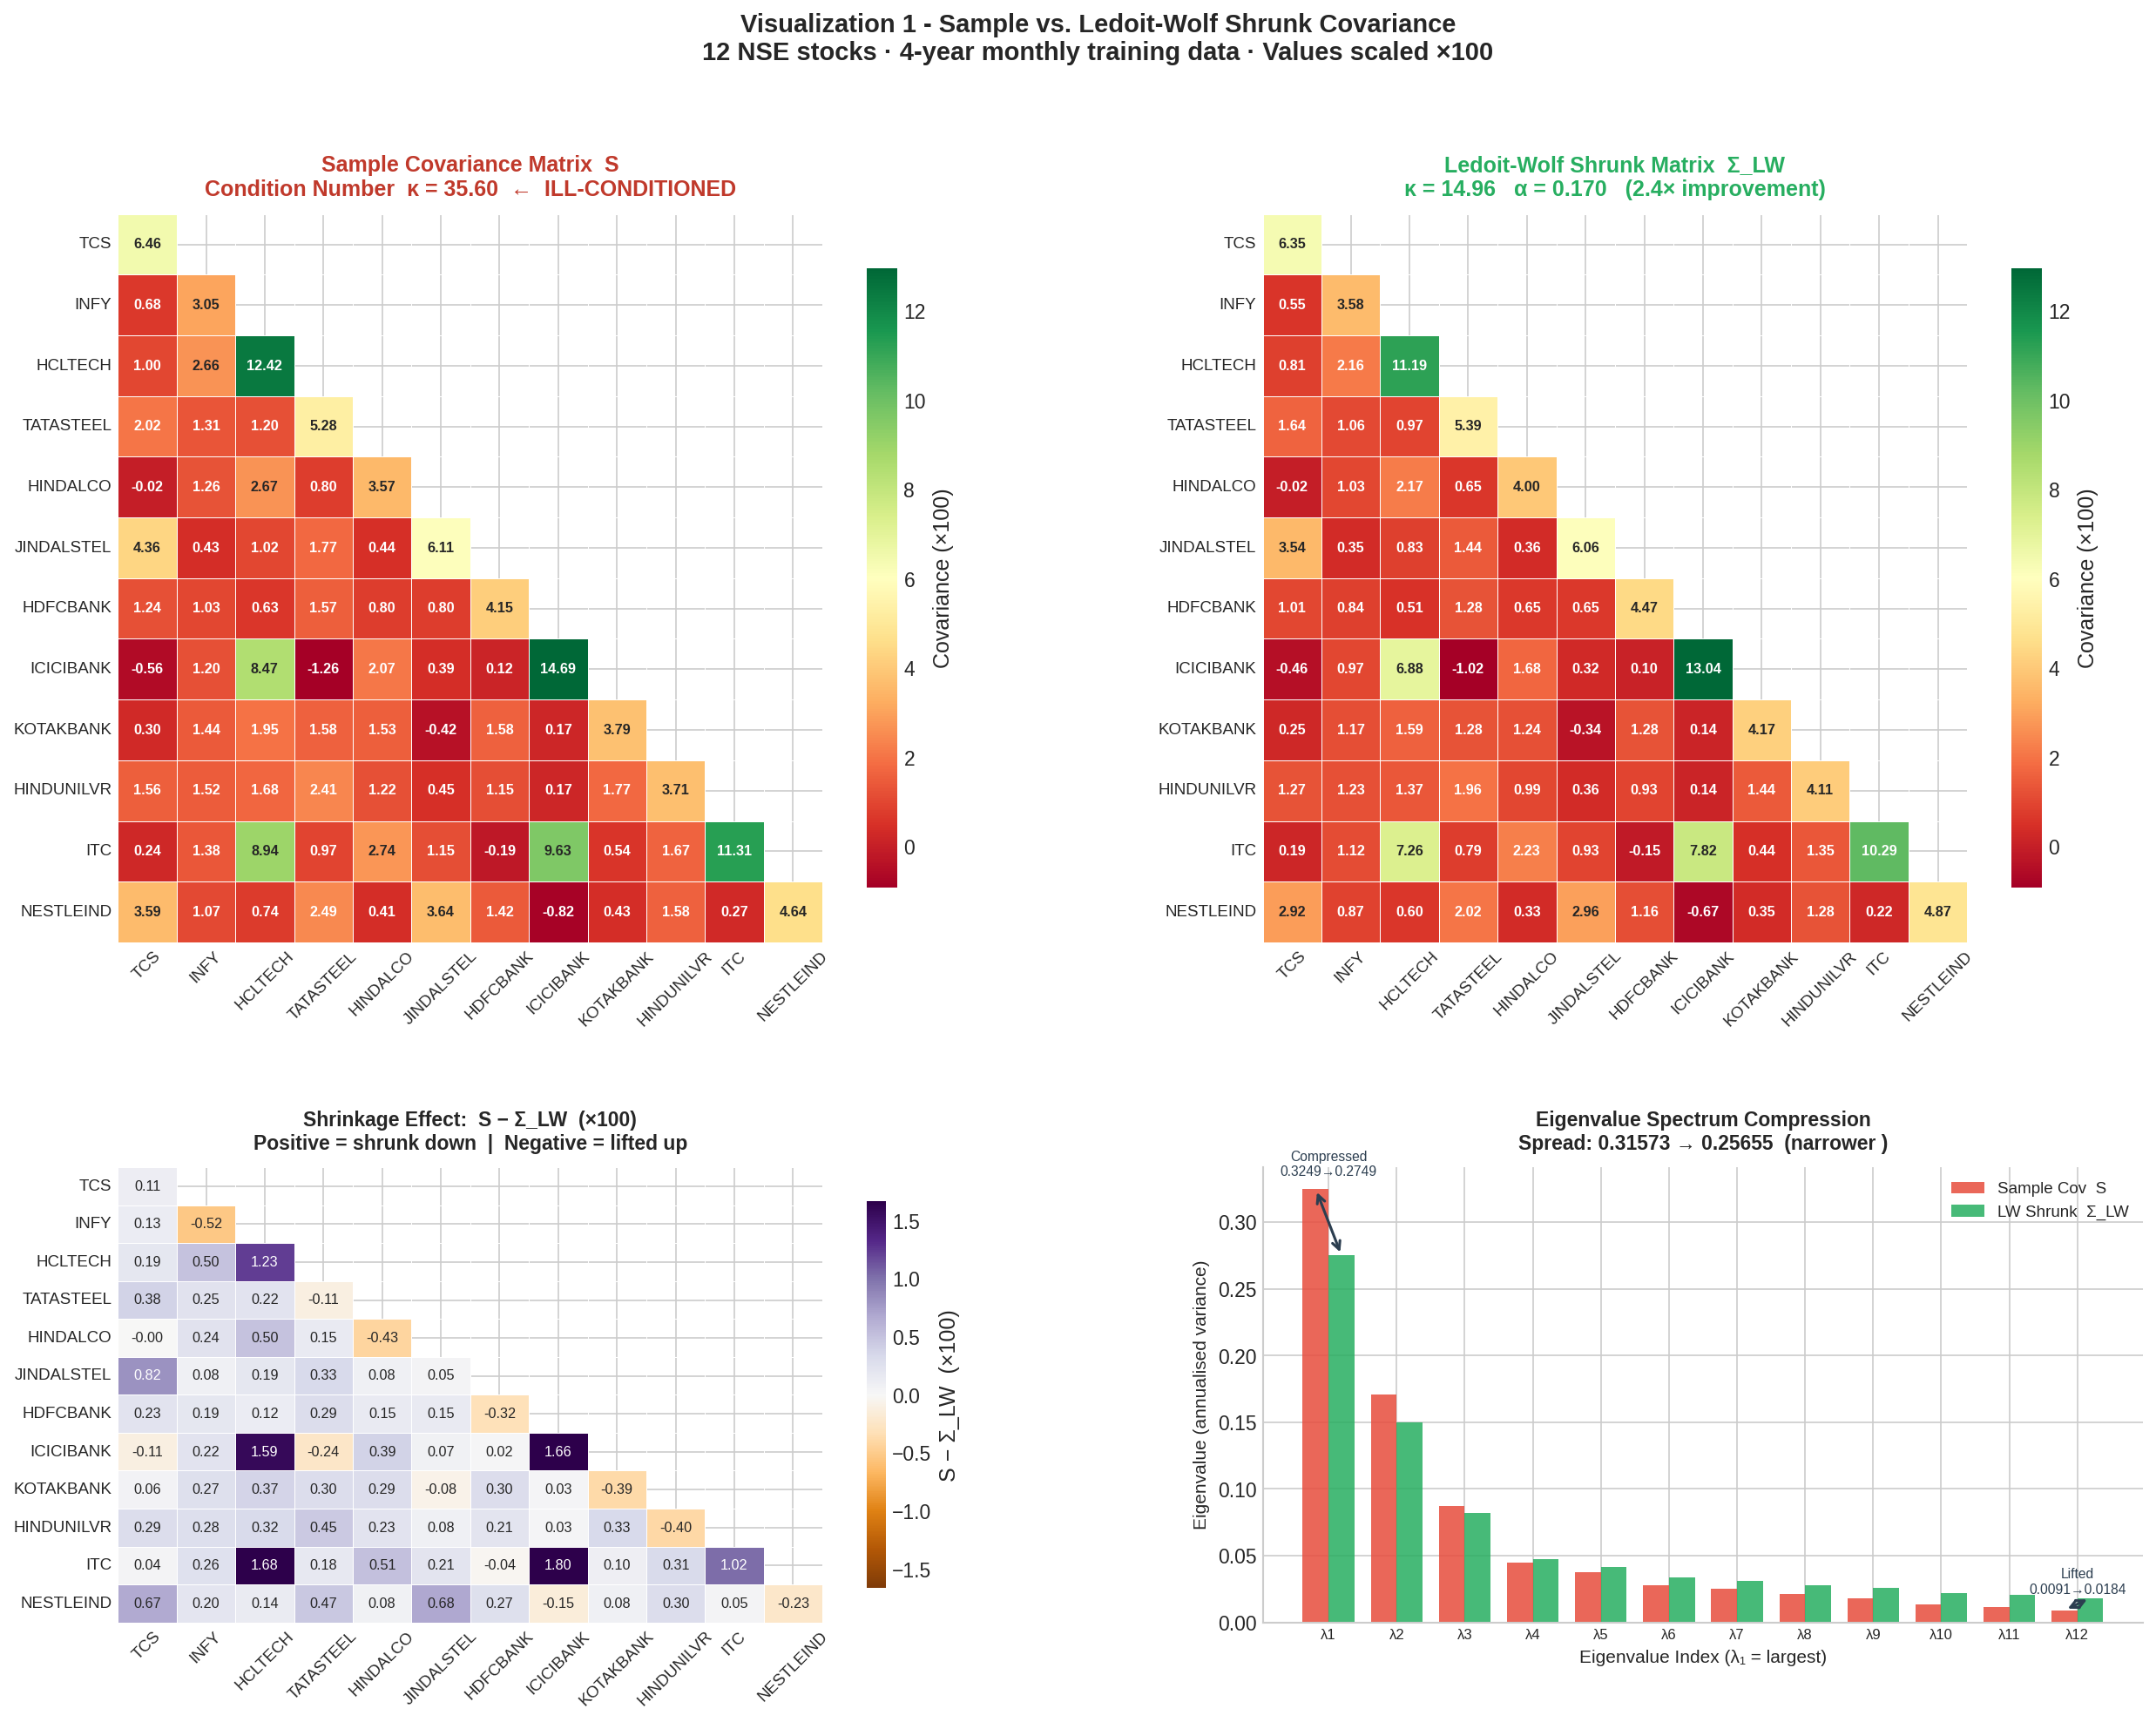

In [318]:
#  Visualization 1 - Covariance Heatmaps + Eigenvalue Spectrum 
# Scale covariance × 100 for readability (0.05 → 5.0)
# Show lower triangle only to reduce clutter
SCALE = 100   # display in % units
S_disp  = S * SCALE
LW_disp = Sigma_LW * SCALE
mask_upper = np.triu(np.ones_like(S_disp.values, dtype=bool), k=1)  # hide upper triangle
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.38, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])   # Sample Cov
ax2 = fig.add_subplot(gs[0, 1])   # LW Cov
ax3 = fig.add_subplot(gs[1, 0])   # Difference heatmap
ax4 = fig.add_subplot(gs[1, 1])   # Eigenvalue spectrum
#  Shared colour scale (lower triangle values only) 
tri_vals = S_disp.values[~mask_upper]
vmin_cov, vmax_cov = np.percentile(tri_vals, 1), np.percentile(tri_vals, 99)
common_kw = dict(
    mask=mask_upper, cmap='RdYlGn',
    vmin=vmin_cov, vmax=vmax_cov,
    annot=True, fmt='.2f', annot_kws={'size': 7.8, 'weight': 'bold'},
    linewidths=0.4, linecolor='white',
    xticklabels=LABELS, yticklabels=LABELS,
    cbar_kws={'label': 'Covariance (×100)', 'shrink': 0.85}
)
sns.heatmap(S_disp,  ax=ax1, **common_kw)
sns.heatmap(LW_disp, ax=ax2, **common_kw)
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
ax1.set_title(
    f'Sample Covariance Matrix  S\nCondition Number  κ = {kappa_S:.2f}  ←  ILL-CONDITIONED',
    fontsize=12, fontweight='bold', pad=10, color='#c0392b'
)
ax2.set_title(
    f'Ledoit-Wolf Shrunk Matrix  Σ_LW\nκ = {kappa_LW:.2f}   α = {alpha_lw:.3f}   ({kappa_S/kappa_LW:.1f}× improvement)',
    fontsize=12, fontweight='bold', pad=10, color='#27ae60'
)
#  Difference heatmap: Shrinkage Effect  (S - Σ_LW) × 100 
diff    = (S - Sigma_LW) * SCALE
abs_max = np.percentile(np.abs(diff.values[~mask_upper]), 98)
sns.heatmap(
    diff, ax=ax3, mask=mask_upper,
    cmap='PuOr', center=0, vmin=-abs_max, vmax=abs_max,
    annot=True, fmt='.2f', annot_kws={'size': 7.8},
    linewidths=0.4, linecolor='white',
    xticklabels=LABELS, yticklabels=LABELS,
    cbar_kws={'label': 'S − Σ_LW  (×100)', 'shrink': 0.85}
)
ax3.tick_params(axis='x', rotation=45, labelsize=9)
ax3.tick_params(axis='y', rotation=0,  labelsize=9)
ax3.set_title('Shrinkage Effect:  S − Σ_LW  (×100)\nPositive = shrunk down  |  Negative = lifted up',
              fontsize=11, fontweight='bold', pad=10)
#  Eigenvalue Spectrum Comparison 
n_eigs   = N_STOCKS
idx      = np.arange(1, n_eigs + 1)
bar_w    = 0.38
bars_S  = ax4.bar(idx - bar_w/2, eigs_S,  bar_w, label='Sample Cov  S',     color='#e74c3c', alpha=0.85)
bars_LW = ax4.bar(idx + bar_w/2, eigs_LW, bar_w, label='LW Shrunk  Σ_LW',   color='#27ae60', alpha=0.85)
# Annotate compression of extremes
ax4.annotate('', xy=(1 + bar_w/2, eigs_LW[0]),  xytext=(1 - bar_w/2, eigs_S[0]),
             arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.5))
ax4.annotate('', xy=(12 + bar_w/2, eigs_LW[-1]), xytext=(12 - bar_w/2, eigs_S[-1]),
             arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.5))
ax4.text(1, eigs_S[0] * 1.03, f'Compressed\n{eigs_S[0]:.4f}→{eigs_LW[0]:.4f}',
         ha='center', fontsize=7.5, color='#2c3e50')
ax4.text(12, eigs_S[-1] + (eigs_S[0] - eigs_S[-1]) * 0.04,
         f'Lifted\n{eigs_S[-1]:.4f}→{eigs_LW[-1]:.4f}',
         ha='center', fontsize=7.5, color='#2c3e50')
ax4.set_xticks(idx)
ax4.set_xticklabels([f'λ{i}' for i in idx], fontsize=8)
ax4.set_xlabel('Eigenvalue Index (λ₁ = largest)', fontsize=10)
ax4.set_ylabel('Eigenvalue (annualised variance)', fontsize=10)
ax4.set_title(f'Eigenvalue Spectrum Compression\nSpread: {eigs_S[0]-eigs_S[-1]:.5f} → {eigs_LW[0]-eigs_LW[-1]:.5f}  (narrower )',
              fontsize=11, fontweight='bold', pad=10)
ax4.legend(fontsize=9, framealpha=0.9)
ax4.set_ylim(bottom=0)
fig.suptitle(
    'Visualization 1 - Sample vs. Ledoit-Wolf Shrunk Covariance\n'
    '12 NSE stocks · 4-year monthly training data · Values scaled ×100',
    fontsize=14, fontweight='bold', y=0.99
)
plt.savefig('viz1_covariance_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()




In [321]:
#  Rolling Window Weight Analysis (for Viz 3) 
# Compute 12-month rolling Max-Sharpe weights for BOTH Sample MPT and LW-MPT
# across the full monthly data series, to capture the 2023 banking stress period.
WINDOW = 12   # months
dates_roll, weights_mpt_roll, weights_lw_roll, weights_hrp_roll = [], [], [], []
for end_i in range(WINDOW, len(monthly_ret)):
    window_ret = monthly_ret.iloc[end_i - WINDOW: end_i]
    date = monthly_ret.index[end_i]
    S_r  = window_ret.cov() * 12
    mu_r = window_ret.mean() * 12
    # Sample MPT weights
    try:
        wm = max_sharpe(S_r.values, mu_r.values)
    except Exception:
        wm = np.ones(N_STOCKS) / N_STOCKS
    # LW-MPT weights
    try:
        lw_r = LedoitWolf().fit(window_ret.values)
        S_lw_r = lw_r.covariance_ * 12
        wl = max_sharpe(S_lw_r, mu_r.values)
    except Exception:
        wl = np.ones(N_STOCKS) / N_STOCKS
    # HRP weights
    try:
        wh, _, _ = compute_hrp(window_ret)
    except Exception:
        wh = pd.Series(np.ones(N_STOCKS) / N_STOCKS, index=LABELS)
    dates_roll.append(date)
    weights_mpt_roll.append(wm)
    weights_lw_roll.append(wl)
    weights_hrp_roll.append(wh.values if isinstance(wh, pd.Series) else wh)
# Assemble DataFrames
df_mpt_roll = pd.DataFrame(weights_mpt_roll, index=dates_roll, columns=LABELS)
df_lw_roll  = pd.DataFrame(weights_lw_roll,  index=dates_roll, columns=LABELS)
df_hrp_roll = pd.DataFrame(weights_hrp_roll, index=dates_roll, columns=LABELS)




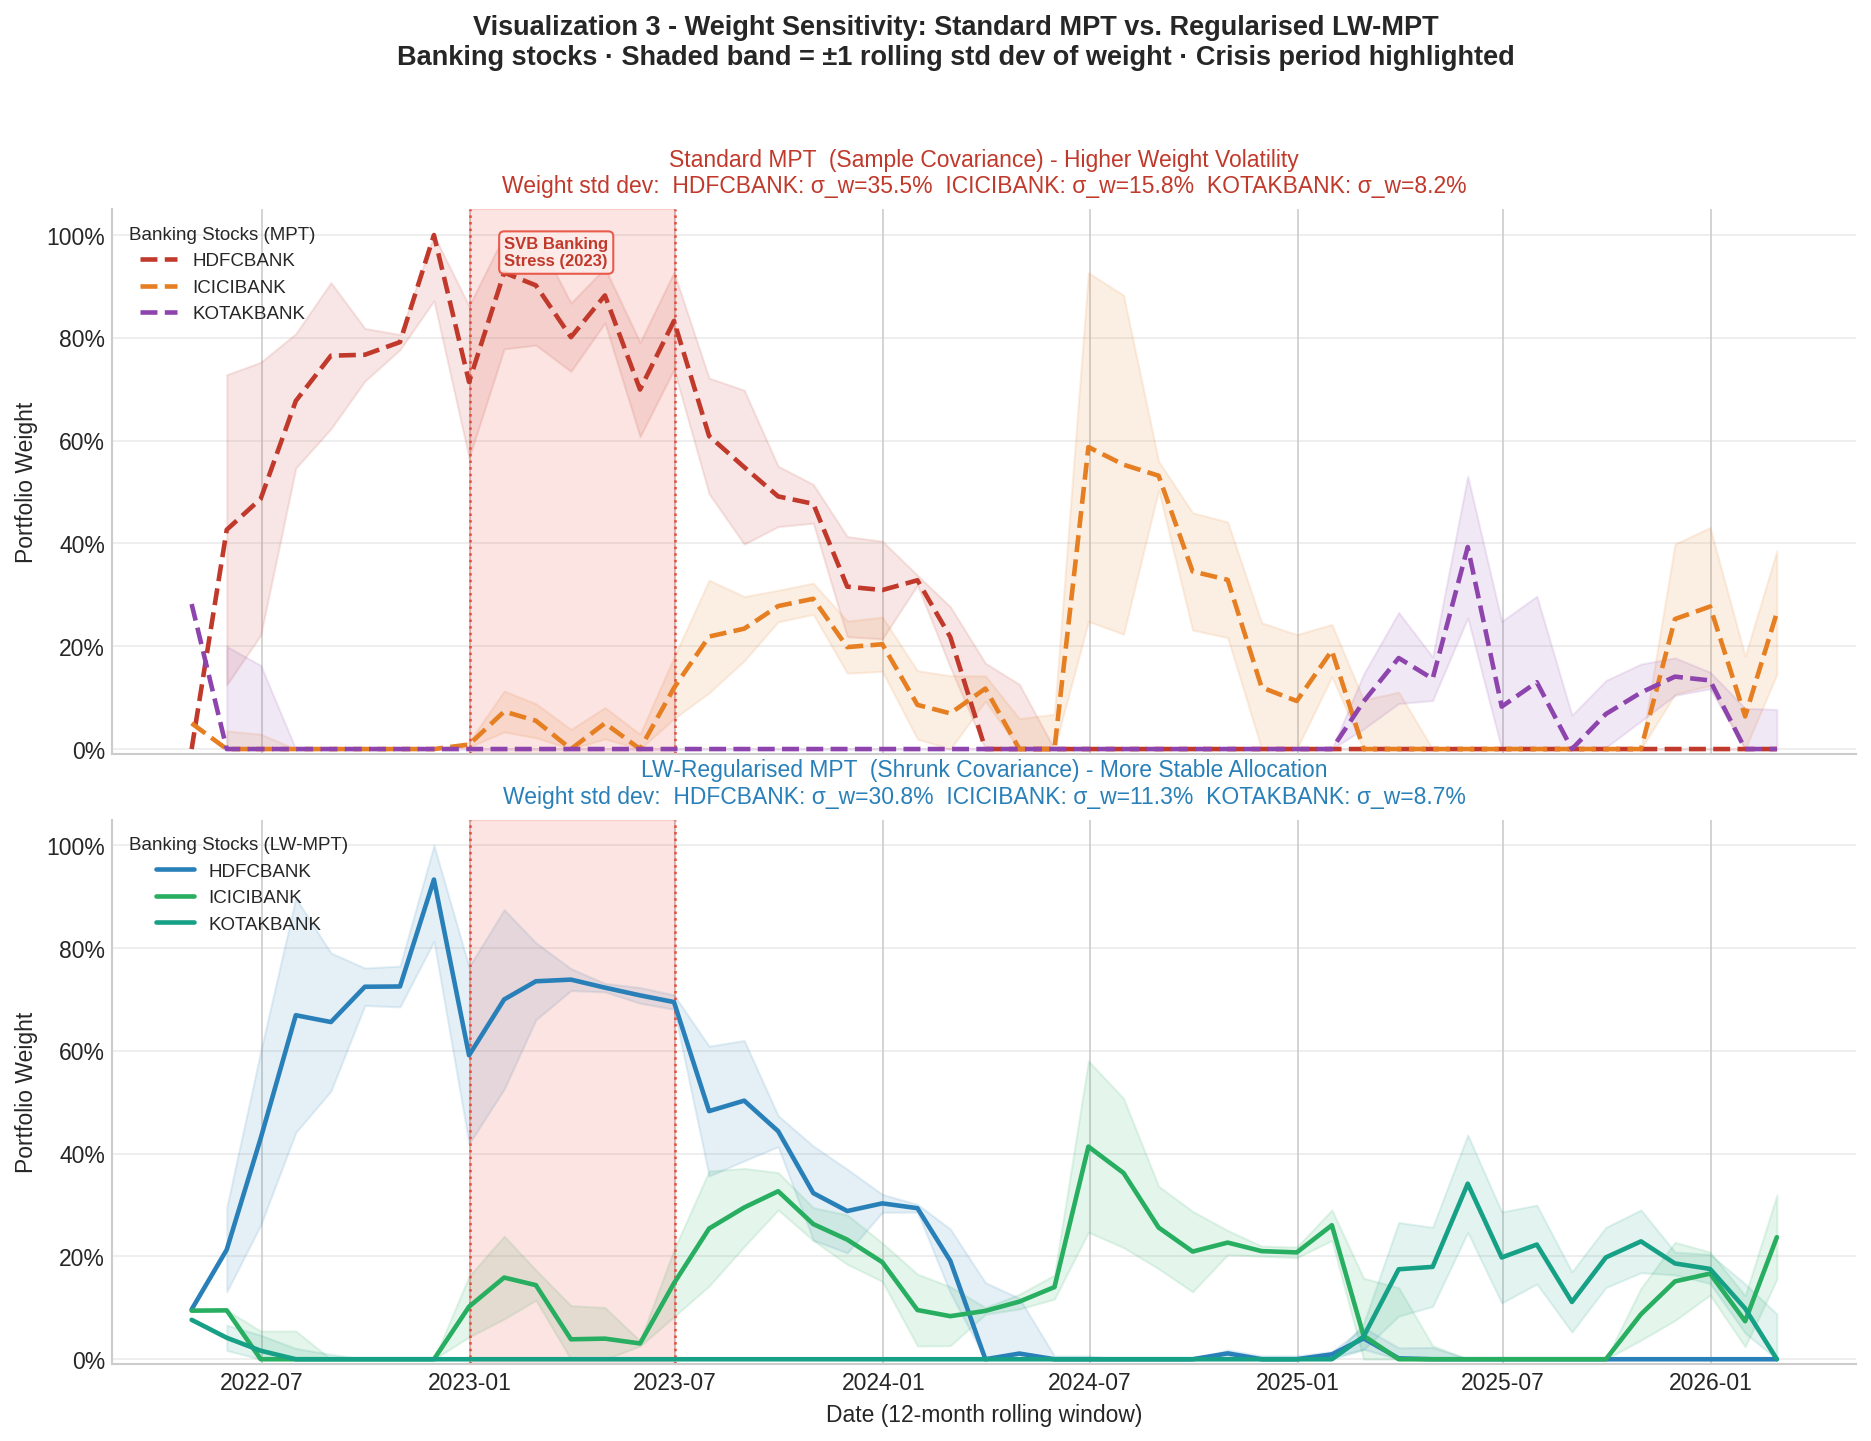

Saved: viz3_weight_sensitivity.png

Weight Volatility Summary - Banking Stocks:
Stock            MPT  σ_w   LW-MPT  σ_w    Reduction
                                                    
HDFCBANK          35.52%       30.83%       13.2%
ICICIBANK         15.84%       11.31%       28.6%
KOTAKBANK          8.15%        8.67%       -6.3%


In [ ]:
#  Visualization 3 - Weight Sensitivity During Banking Crisis 
BANKING_STOCKS = ['HDFCBANK', 'ICICIBANK', 'KOTAKBANK']
CRISIS_START   = pd.Timestamp('2023-01-01')
CRISIS_END     = pd.Timestamp('2023-07-01')
PALETTE_MPT = ['#c0392b', '#e67e22', '#8e44ad']   # red/orange/purple for MPT
PALETTE_LW  = ['#2980b9', '#27ae60', '#16a085']    # blue/green/teal for LW
dates_np = df_mpt_roll.index.to_numpy()
#  Compute per-stock weight range during crisis 
crisis_mask = (df_mpt_roll.index >= CRISIS_START) & (df_mpt_roll.index <= CRISIS_END)
crisis_range_mpt = {b: df_mpt_roll.loc[crisis_mask, b].max() - df_mpt_roll.loc[crisis_mask, b].min()
                    for b in BANKING_STOCKS}
crisis_range_lw  = {b: df_lw_roll.loc[crisis_mask, b].max()  - df_lw_roll.loc[crisis_mask, b].min()
                    for b in BANKING_STOCKS}
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                          gridspec_kw={'hspace': 0.12})
for j, bank in enumerate(BANKING_STOCKS):
    # MPT (top panel)
    axes[0].plot(dates_np, df_mpt_roll[bank].to_numpy(),
                 color=PALETTE_MPT[j], lw=2.2, ls='--', label=bank, zorder=3)
    # Rolling std band
    w_std = df_mpt_roll[bank].rolling(3, min_periods=1).std().to_numpy()
    axes[0].fill_between(dates_np,
                          np.clip(df_mpt_roll[bank].to_numpy() - w_std, 0, None),
                          np.clip(df_mpt_roll[bank].to_numpy() + w_std, None, 1),
                          alpha=0.12, color=PALETTE_MPT[j])
    # LW (bottom panel)
    axes[1].plot(dates_np, df_lw_roll[bank].to_numpy(),
                 color=PALETTE_LW[j], lw=2.2, ls='-', label=bank, zorder=3)
    w_std_lw = df_lw_roll[bank].rolling(3, min_periods=1).std().to_numpy()
    axes[1].fill_between(dates_np,
                          np.clip(df_lw_roll[bank].to_numpy() - w_std_lw, 0, None),
                          np.clip(df_lw_roll[bank].to_numpy() + w_std_lw, None, 1),
                          alpha=0.12, color=PALETTE_LW[j])
for ax in axes:
    # Crisis shading
    ax.axvspan(CRISIS_START, CRISIS_END, alpha=0.15, color='#e74c3c', zorder=1)
    ax.axvline(CRISIS_START, color='#e74c3c', lw=1.2, ls=':', zorder=2)
    ax.axvline(CRISIS_END,   color='#e74c3c', lw=1.2, ls=':', zorder=2)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Portfolio Weight', fontsize=11)
    ax.set_ylim(bottom=-0.01)
    ax.grid(axis='y', alpha=0.4)
# Crisis label
ypos = axes[0].get_ylim()[1] * 0.95
axes[0].text(CRISIS_START + pd.Timedelta(days=30), ypos,
             'SVB Banking\nStress (2023)', fontsize=8, color='#c0392b',
             va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', ec='#e74c3c', alpha=0.9))
# Stock legends
axes[0].legend(title='Banking Stocks (MPT)', fontsize=9, title_fontsize=9,
               loc='upper left', framealpha=0.9)
axes[1].legend(title='Banking Stocks (LW-MPT)', fontsize=9, title_fontsize=9,
               loc='upper left', framealpha=0.9)
# Sub-titles with volatility stats
vol_mpt_str = '  '.join([f'{b}: σ_w={df_mpt_roll[b].std():.1%}' for b in BANKING_STOCKS])
vol_lw_str  = '  '.join([f'{b}: σ_w={df_lw_roll[b].std():.1%}' for b in BANKING_STOCKS])
axes[0].set_title(f'Standard MPT  (Sample Covariance) - Higher Weight Volatility\n'
                  f'Weight std dev:  {vol_mpt_str}',
                  fontsize=11, pad=8, color='#c0392b')
axes[1].set_title(f'LW-Regularised MPT  (Shrunk Covariance) - More Stable Allocation\n'
                  f'Weight std dev:  {vol_lw_str}',
                  fontsize=11, pad=8, color='#2980b9')
axes[1].set_xlabel('Date (12-month rolling window)', fontsize=11)
fig.suptitle(
    'Visualization 3 - Weight Sensitivity: Standard MPT vs. Regularised LW-MPT\n'
    'Banking stocks · Shaded band = ±1 rolling std dev of weight · Crisis period highlighted',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('viz3_weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
# Table summary
print('\nWeight Volatility Summary - Banking Stocks:')
print(f'{"Stock":<14} {"MPT  σ_w":>10} {"LW-MPT  σ_w":>13} {"Reduction":>12}')
print(' ' * 52)
for bank in BANKING_STOCKS:
    vm = df_mpt_roll[bank].std()
    vl = df_lw_roll[bank].std()
    print(f'{bank:<14} {vm:>9.2%} {vl:>12.2%} {(1-vl/vm):>11.1%}')



---
## Part 2-Structural Regularization with Hierarchical Risk Parity (HRP)

HRP regularizes the portfolio by capturing the **topology of risk** through hierarchical clustering.

### Algorithm:
1. **Correlation-based Distance**: $D_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$
2. **Hierarchical Clustering**
3. **Quasi-Diagonalization**: reorder assets so correlated ones are adjacent
4. **Recursive Bisection**: allocate capital inversely proportional to cluster variance

Uses **daily returns** for finer resolution.


In [325]:
#  Clustering on Training Daily Returns 
corr_train_d = train_d.corr()
dist_train   = np.sqrt(np.clip(0.5 * (1.0 - corr_train_d.values), 0, 1))
np.fill_diagonal(dist_train, 0.0)
Z_train   = linkage(squareform(dist_train), method='ward')
sort_ix_d = leaves_list(Z_train)
# Cluster assignment (k=4 clusters for interpretability)
K = 4
cluster_ids = fcluster(Z_train, t=K, criterion='maxclust')
# Per-cluster statistics for data-driven labeling
cov_ann_d   = train_d.cov() * 252
ann_vol     = np.sqrt(np.diag(cov_ann_d.values))
ann_ret     = train_d.mean().values * 252
print(f'Hierarchical Clusters (k={K}) - data-driven labels:')
print()
cluster_info = {}
for k in range(1, K + 1):
    members = [LABELS[i] for i, c in enumerate(cluster_ids) if c == k]
    idxs    = [i for i, c in enumerate(cluster_ids) if c == k]
    mean_vol = np.mean(ann_vol[idxs])
    mean_ret = np.mean(ann_ret[idxs])
    intra_corr = corr_train_d.values[np.ix_(idxs, idxs)]
    np.fill_diagonal(intra_corr, np.nan)
    mean_rho = np.nanmean(intra_corr)
    cluster_info[k] = {
        'members': members, 'mean_vol': mean_vol,
        'mean_ret': mean_ret, 'mean_rho': mean_rho
    }
    print(f'  Cluster {k}: {members}')
    print(f'    Mean Ann. Vol : {mean_vol:.1%}  |  Mean Ann. Ret: {mean_ret:.1%}  |  Intra-ρ̄: {mean_rho:.3f}')




Hierarchical Clusters (k=4) - data-driven labels:

  Cluster 1: ['HCLTECH', 'ICICIBANK', 'ITC']
    Mean Ann. Vol : 35.4%  |  Mean Ann. Ret: 26.5%  |  Intra-ρ̄: 0.724
  Cluster 2: ['TCS', 'JINDALSTEL', 'NESTLEIND']
    Mean Ann. Vol : 22.8%  |  Mean Ann. Ret: 16.1%  |  Intra-ρ̄: 0.664
  Cluster 3: ['INFY', 'HINDALCO', 'KOTAKBANK']
    Mean Ann. Vol : 22.2%  |  Mean Ann. Ret: 10.5%  |  Intra-ρ̄: 0.498
  Cluster 4: ['TATASTEEL', 'HDFCBANK', 'HINDUNILVR']
    Mean Ann. Vol : 19.8%  |  Mean Ann. Ret: 13.3%  |  Intra-ρ̄: 0.366


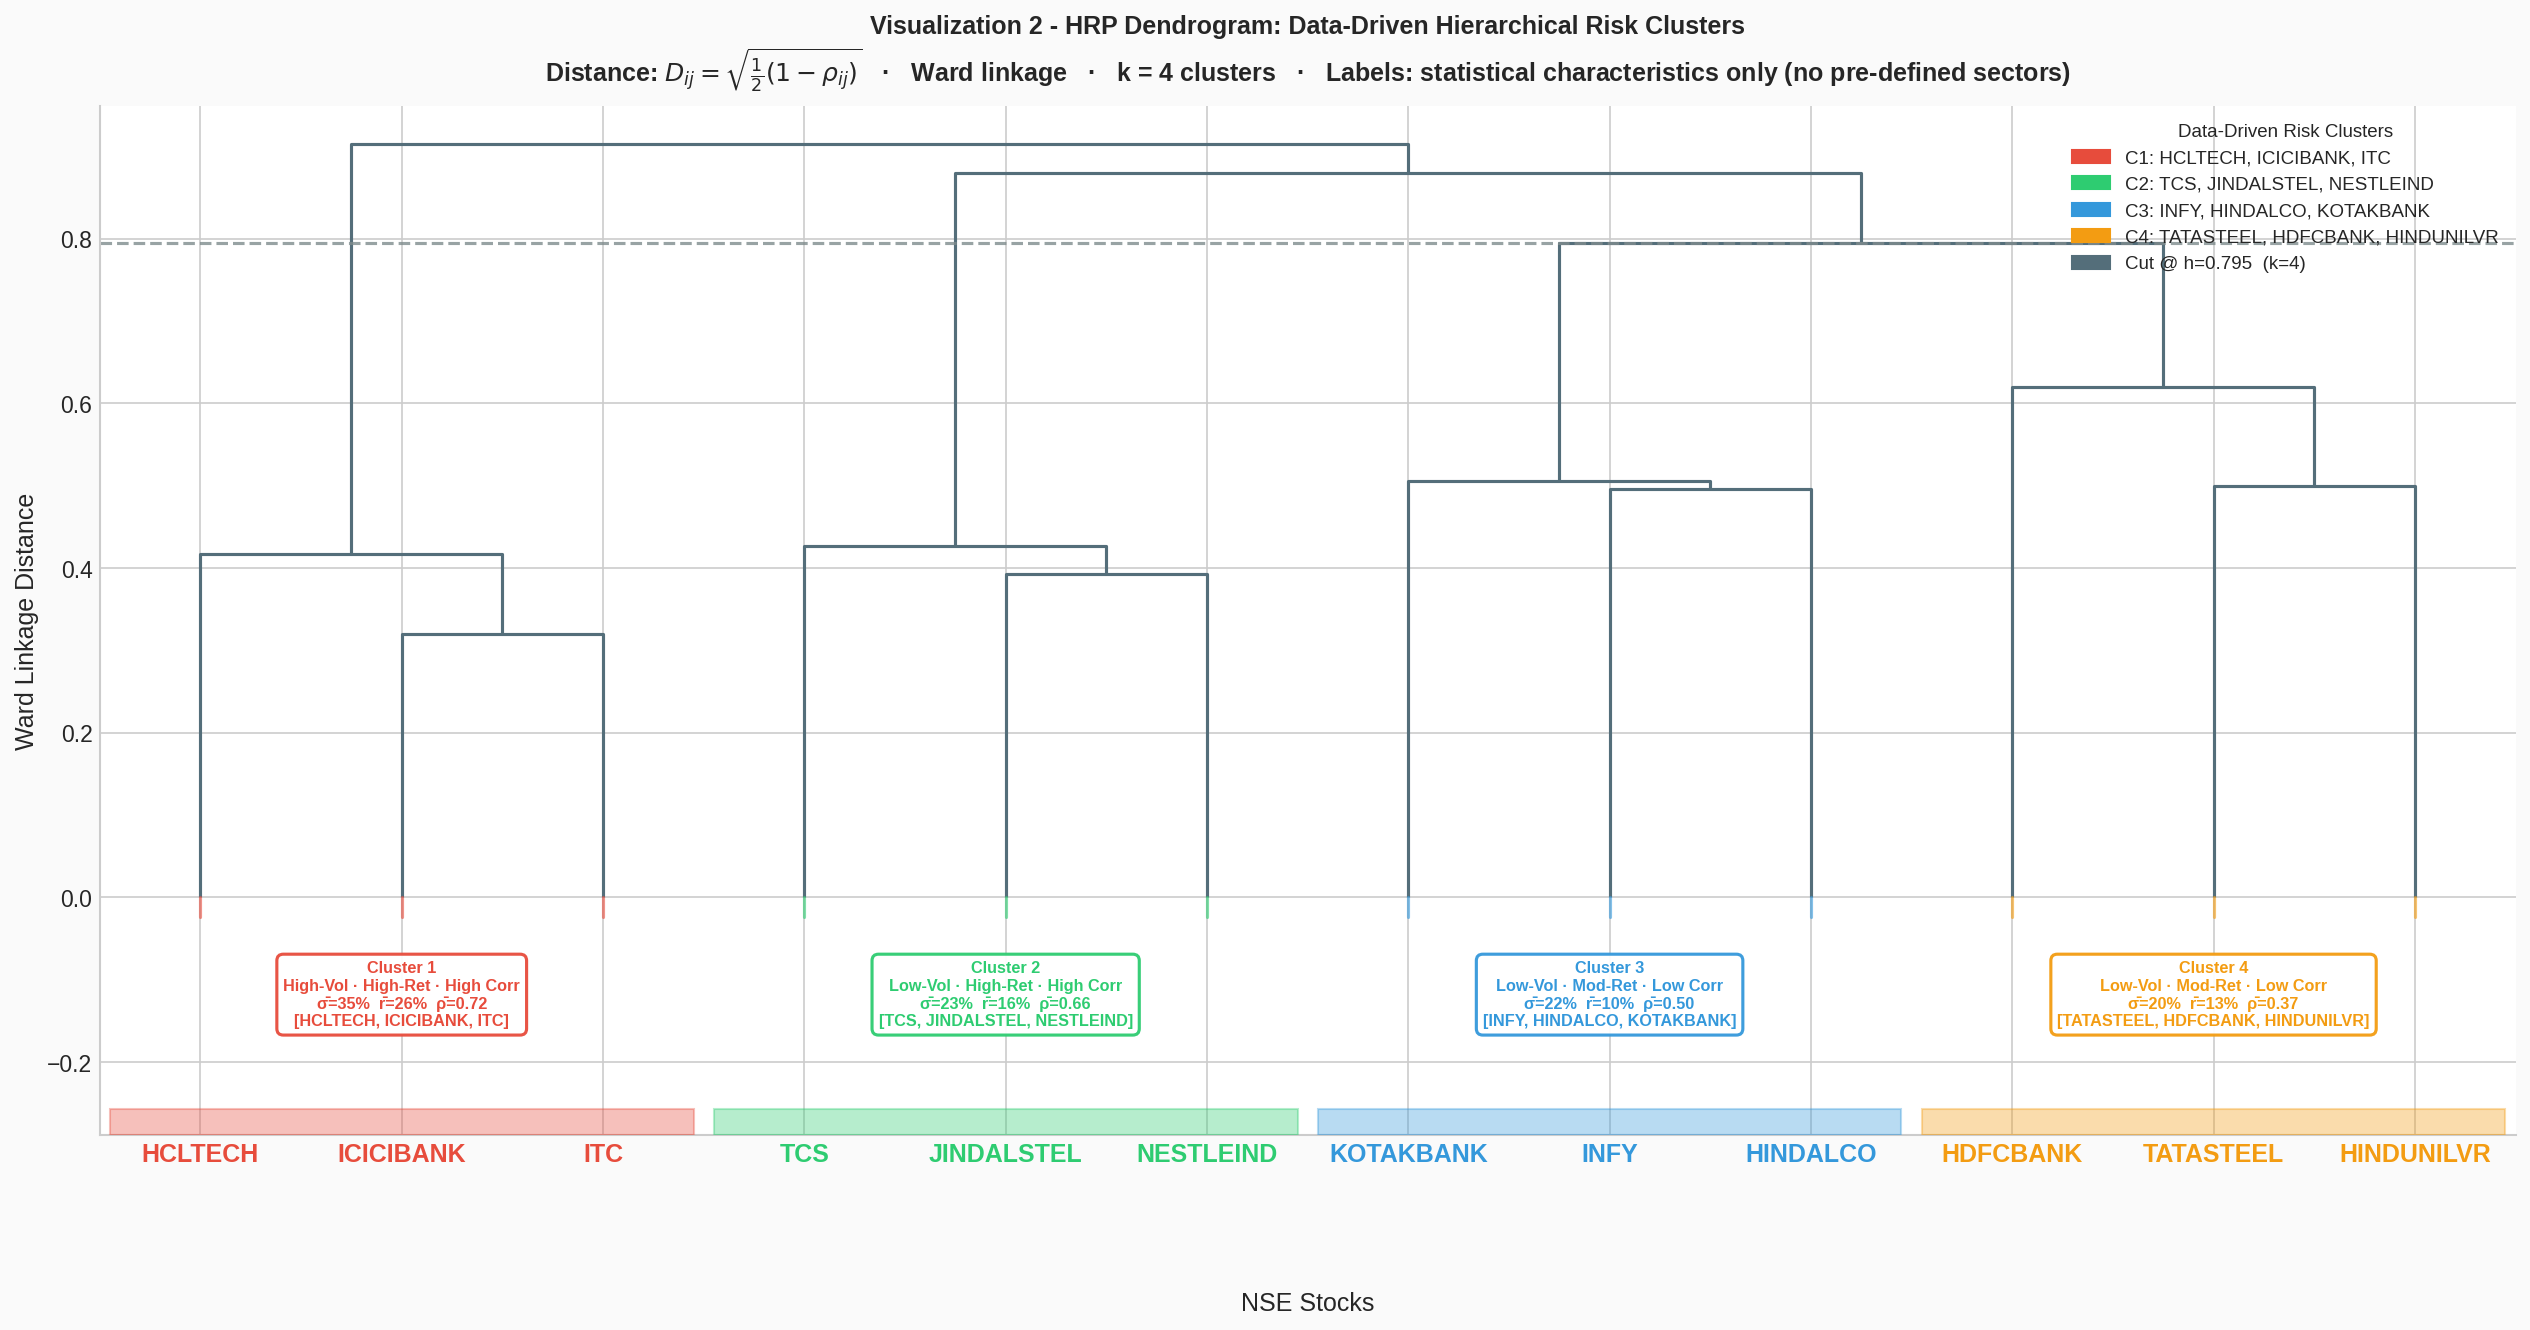


Data-Driven Cluster Summary:
Cluster      Members                                     Vol     Ret      ρ̄ Tag
                                                                                               
  C1        ['HCLTECH', 'ICICIBANK', 'ITC']          35.4%  26.5%  0.724   High-Vol · High-Ret · High Corr
  C2        ['TCS', 'JINDALSTEL', 'NESTLEIND']       22.8%  16.1%  0.664   Low-Vol · High-Ret · High Corr
  C3        ['INFY', 'HINDALCO', 'KOTAKBANK']        22.2%  10.5%  0.498   Low-Vol · Mod-Ret · Low Corr
  C4        ['TATASTEEL', 'HDFCBANK', 'HINDUNILVR']  19.8%  13.3%  0.366   Low-Vol · Mod-Ret · Low Corr


In [326]:
#  Visualization 2 - HRP Dendrogram with Data-Driven Cluster Labels 
#  Build dynamic labels from cluster statistics 
def cluster_tag(info):
    vol_tag = 'High-Vol'  if info['mean_vol'] > 0.28 else 'Low-Vol'
    ret_tag = 'High-Ret'  if info['mean_ret'] > 0.14 else 'Mod-Ret'
    rho_tag = 'High Corr' if info['mean_rho'] > 0.58 else 'Low Corr'
    return f"{vol_tag} · {ret_tag} · {rho_tag}"
CLUSTER_COLORS = {1: '#e74c3c', 2: '#2ecc71', 3: '#3498db', 4: '#f39c12'}
# Per-stock color from its cluster id
leaf_col = {LABELS[i]: CLUSTER_COLORS[cluster_ids[i]] for i in range(N_STOCKS)}
#  Draw dendrogram (all branches neutral grey for clarity) 
fig, ax = plt.subplots(figsize=(17, 9))
fig.patch.set_facecolor('#fafafa')
dn = dendrogram(
    Z_train,
    labels=LABELS,
    ax=ax,
    color_threshold=0,              # all branches same color → clean look
    above_threshold_color='#546e7a',
    leaf_font_size=12,
    leaf_rotation=0,
)
# Color x-axis tick labels by cluster
for lbl_obj in ax.get_xticklabels():
    tk = lbl_obj.get_text()
    lbl_obj.set_color(leaf_col[tk])
    lbl_obj.set_fontweight('bold')
    lbl_obj.set_fontsize(12)
#  Draw cluster span bars + annotation boxes 
x_pos_map = {lbl: i * 10 + 5 for i, lbl in enumerate(dn['ivl'])}
cluster_spans = {}
for lbl in LABELS:
    k = cluster_ids[LABELS.index(lbl)]
    cluster_spans.setdefault(k, []).append(x_pos_map[lbl])
ymax = ax.get_ylim()[1]
box_y = -ymax * 0.08
for k, xpos_list in sorted(cluster_spans.items()):
    x0 = min(xpos_list) - 4.5
    x1 = max(xpos_list) + 4.5
    xc = (x0 + x1) / 2
    # Span rectangle at bottom of dendrogram
    ax.axvspan(x0, x1, ymin=0, ymax=0.025, alpha=0.35, color=CLUSTER_COLORS[k], zorder=4)
    # Vertical tick lines connecting labels to spans
    for xp in xpos_list:
        ax.plot([xp, xp], [0, -ymax * 0.025], color=CLUSTER_COLORS[k], lw=1.5, alpha=0.6)
    # Annotation box
    info  = cluster_info[k]
    label = (f"Cluster {k}\n"
             f"{cluster_tag(info)}\n"
             f"σ̄={info['mean_vol']:.0%}  r̄={info['mean_ret']:.0%}  ρ̄={info['mean_rho']:.2f}\n"
             f"[{', '.join(info['members'])}]")
    ax.text(xc, box_y, label,
            ha='center', va='top', fontsize=7.8,
            color=CLUSTER_COLORS[k], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='white',
                      ec=CLUSTER_COLORS[k], lw=1.5, alpha=0.95))
#  Cut-height dashed line 
cut_h = Z_train[:, 2][-K + 1]
ax.axhline(cut_h, color='#7f8c8d', lw=1.5, ls='--', alpha=0.8,
           label=f'Cut height (k={K} clusters) = {cut_h:.3f}')
#  Legend 
patches = [mpatches.Patch(color=CLUSTER_COLORS[k],
                           label=f'C{k}: {", ".join(cluster_info[k]["members"])}')
           for k in sorted(cluster_spans)]
patches.append(mpatches.Patch(color='#546e7a', label=f'Cut @ h={cut_h:.3f}  (k={K})'))
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.95,
          title='Data-Driven Risk Clusters', title_fontsize=9)
ax.set_ylim(bottom=-ymax * 0.30)
ax.set_xlabel('NSE Stocks', fontsize=12, labelpad=60)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
ax.set_title(
    'Visualization 2 - HRP Dendrogram: Data-Driven Hierarchical Risk Clusters\n'
    r'Distance: $D_{ij} = \sqrt{\frac{1}{2}(1-\rho_{ij})}$   ·   Ward linkage   ·   '
    f'k = {K} clusters   ·   Labels: statistical characteristics only (no pre-defined sectors)',
    fontsize=12, fontweight='bold', pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_hrp_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Data-Driven Cluster Summary:')
print(f'{"Cluster":<12} {"Members":<40} {"Vol":>6} {"Ret":>7} {"ρ̄":>7} {"Tag"}')
print(' ' * 95)
for k in range(1, K + 1):
    info = cluster_info[k]
    print(f'  C{k}        {str(info["members"]):<40} {info["mean_vol"]:>5.1%} {info["mean_ret"]:>6.1%} '
          f'{info["mean_rho"]:>6.3f}   {cluster_tag(info)}')




In [327]:
#  HRP Weights (Training Window) 
w_hrp, _, _ = compute_hrp(train_d)
# MPT min-variance for comparison (daily-based)
cov_d_ann = train_d.cov().values * 252
mu_d_ann  = train_d.mean().values * 252
w_mpt_d   = pd.Series(min_variance(cov_d_ann), index=LABELS)
print(f'{"Stock":<14} {"HRP":>8} {"Min-Var MPT":>12} {"Equal Wt":>10}')
print('-' * 48)
for lbl in LABELS:
    print(f'{lbl:<14} {w_hrp[lbl]:>7.2%} {w_mpt_d[lbl]:>11.2%} {1/N_STOCKS:>9.2%}')
print('-' * 48)
# Concentration
for name, w in [('HRP', w_hrp), ('Min-Var MPT', w_mpt_d), ('Equal Weight', w_eq)]:
    hhi = np.sum(w.values**2)
    print(f'{name:<14} HHI = {hhi:.4f}')




Stock               HRP  Min-Var MPT   Equal Wt
------------------------------------------------
TCS              9.99%       4.84%     8.33%
INFY             8.31%      10.69%     8.33%
HCLTECH          4.39%       0.00%     8.33%
TATASTEEL       10.68%       9.99%     8.33%
HINDALCO         8.23%      10.66%     8.33%
JINDALSTEL       5.85%       0.69%     8.33%
HDFCBANK        16.06%      16.51%     8.33%
ICICIBANK        2.10%       1.20%     8.33%
KOTAKBANK       10.91%       5.78%     8.33%
HINDUNILVR      13.11%      24.27%     8.33%
ITC              2.72%       0.00%     8.33%
NESTLEIND        7.66%      15.35%     8.33%
------------------------------------------------
HRP            HHI = 0.1023
Min-Var MPT    HHI = 0.1484
Equal Weight   HHI = 0.0833


Average Portfolio Turnover per Rebalance (1-way):
  HRP          : 0.0911  (9.11%)
  Min-Var MPT  : 0.1546  (15.46%)
  LW-MPT       : 0.1375  (13.75%)

  HRP reduces turnover by: 41.1% vs MPT
  LW reduces turnover by : 11.1% vs MPT


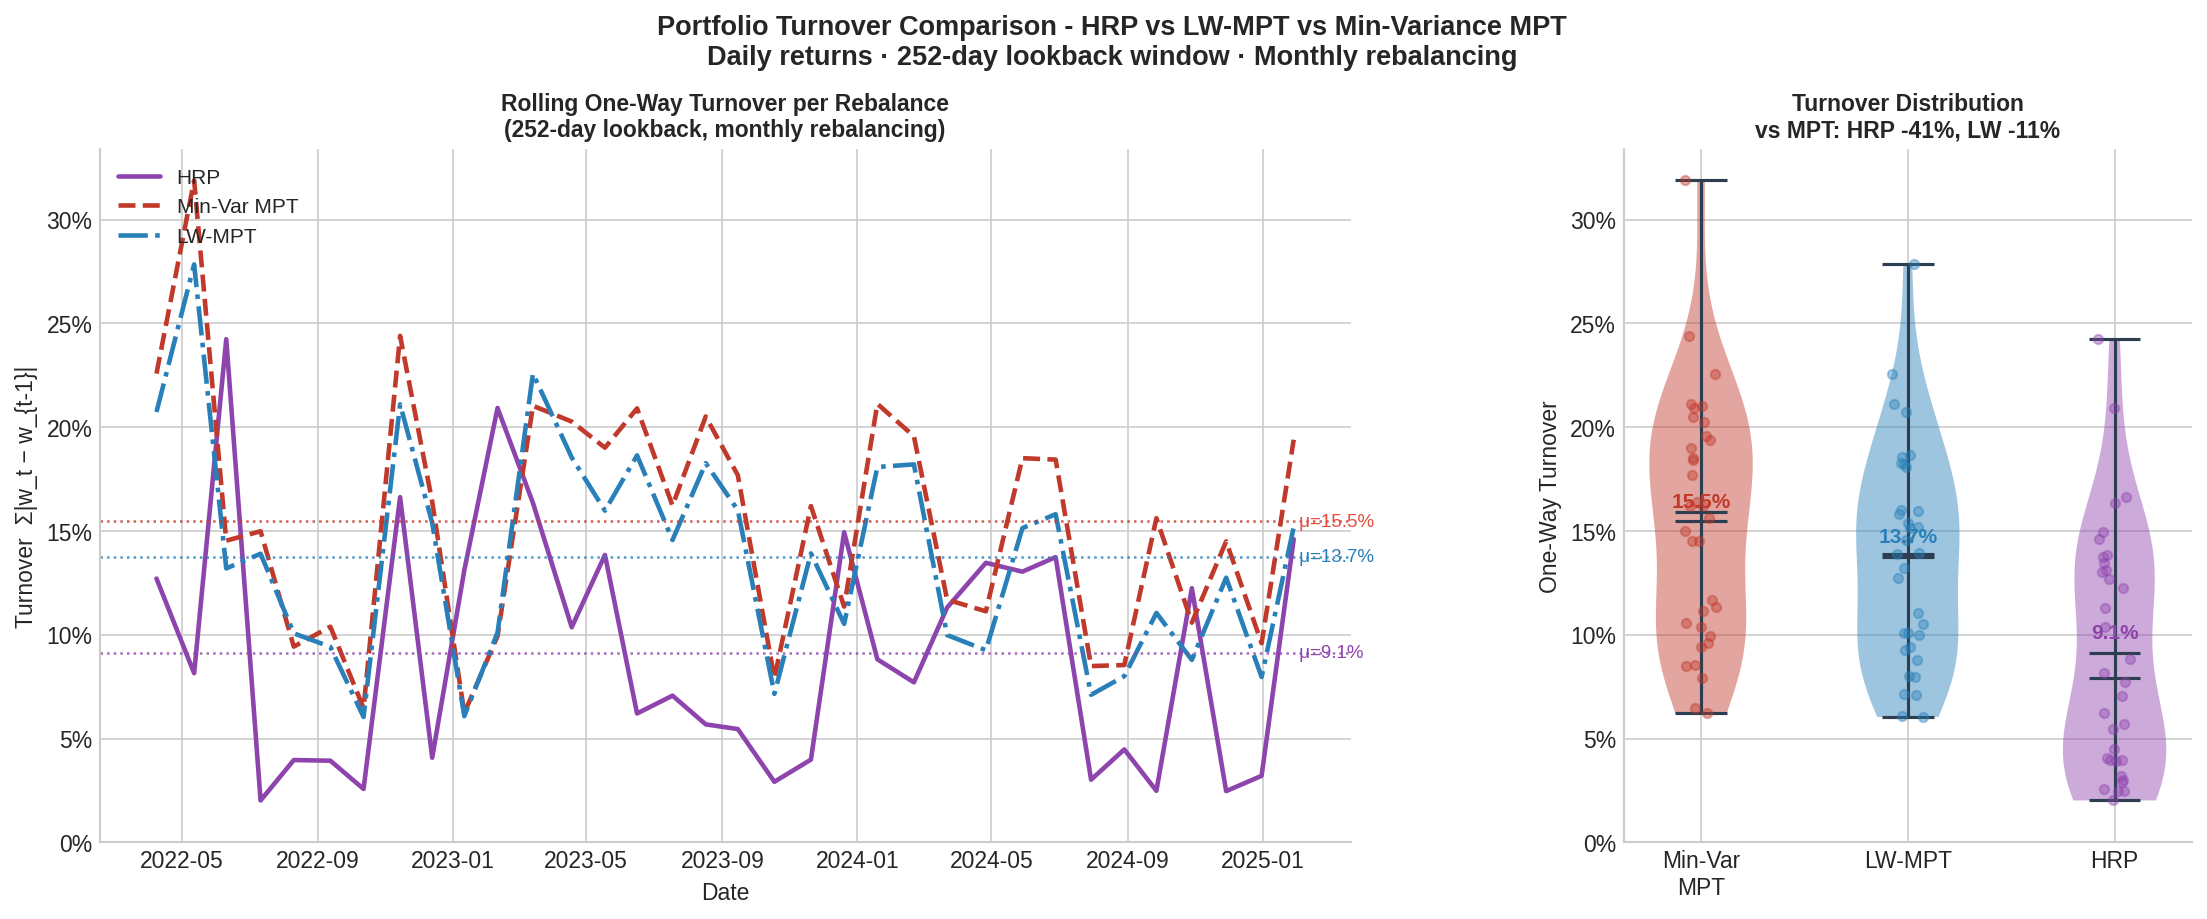

Saved: viz5_turnover_comparison_all.png


In [328]:
# ── Portfolio Turnover Comparison: HRP vs MPT vs LW-MPT ───────────────────────

LOOKBACK   = 252
REBAL_FREQ = 21

rebal_dates = train_d.index[LOOKBACK::REBAL_FREQ]
hist_hrp, hist_mpt_mv, hist_lw_mv = [], [], []

for date in rebal_dates:
    loc    = train_d.index.get_loc(date)
    window = train_d.iloc[loc - LOOKBACK: loc]

    try:
        wh, _, _ = compute_hrp(window)
    except Exception:
        wh = pd.Series(np.ones(N_STOCKS) / N_STOCKS, index=LABELS)

    cov_w = window.cov().values * 252
    try:
        wm = pd.Series(min_variance(cov_w), index=LABELS)
    except Exception:
        wm = pd.Series(np.ones(N_STOCKS) / N_STOCKS, index=LABELS)
        
    try:
        # LW shrinkage using LedoitWolf from training data block
        lw_op = LedoitWolf().fit(window.values)
        cov_lw = lw_op.covariance_ * 252
        wl = pd.Series(min_variance(cov_lw), index=LABELS)
    except Exception:
        wl = pd.Series(np.ones(N_STOCKS) / N_STOCKS, index=LABELS)

    hist_hrp.append(wh.values)
    hist_mpt_mv.append(wm.values)
    hist_lw_mv.append(wl.values)

def turnover_series(wh_list):
    arr  = np.array(wh_list)
    return np.sum(np.abs(np.diff(arr, axis=0)), axis=1)

series_hrp    = turnover_series(hist_hrp)
series_mpt_mv = turnover_series(hist_mpt_mv)
series_lw_mv  = turnover_series(hist_lw_mv)

to_hrp        = series_hrp.mean()
to_mpt_mv     = series_mpt_mv.mean()
to_lw_mv      = series_lw_mv.mean()

print('Average Portfolio Turnover per Rebalance (1-way):')
print(f'  HRP          : {to_hrp:.4f}  ({to_hrp:.2%})')
print(f'  Min-Var MPT  : {to_mpt_mv:.4f}  ({to_mpt_mv:.2%})')
print(f'  LW-MPT       : {to_lw_mv:.4f}  ({to_lw_mv:.2%})')

print(f'\n  HRP reduces turnover by: {(1 - to_hrp/to_mpt_mv):.1%} vs MPT')
print(f'  LW reduces turnover by : {(1 - to_lw_mv/to_mpt_mv):.1%} vs MPT')

# ── Turnover Plot: Time Series + Distribution ─────────────────────────────────
dates_rebal_np = rebal_dates[1:].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                          gridspec_kw={'width_ratios': [2.2, 1], 'wspace': 0.3})

# Left: rolling turnover time series
axes[0].plot(dates_rebal_np, series_hrp,    label='HRP',          color='#8e44ad', lw=2.2)
axes[0].plot(dates_rebal_np, series_mpt_mv, label='Min-Var MPT',  color='#c0392b', lw=2.2, ls='--')
axes[0].plot(dates_rebal_np, series_lw_mv,  label='LW-MPT',       color='#2980b9', lw=2.2, ls='-.')

# Mean lines
axes[0].axhline(to_hrp,    color='#8e44ad', lw=1.2, ls=':', alpha=0.8)
axes[0].axhline(to_mpt_mv, color='#c0392b', lw=1.2, ls=':', alpha=0.8)
axes[0].axhline(to_lw_mv,  color='#2980b9', lw=1.2, ls=':', alpha=0.8)

axes[0].text(dates_rebal_np[-1], to_hrp,    f' μ={to_hrp:.1%}',    va='center', color='#8e44ad', fontsize=9)
axes[0].text(dates_rebal_np[-1], to_mpt_mv, f' μ={to_mpt_mv:.1%}', va='center', color='#e74c3c', fontsize=9)
axes[0].text(dates_rebal_np[-1], to_lw_mv,  f' μ={to_lw_mv:.1%}',  va='center', color='#2980b9', fontsize=9)

axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_title('Rolling One-Way Turnover per Rebalance\n(252-day lookback, monthly rebalancing)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Turnover  Σ|w_t − w_{t-1}|', fontsize=11)
axes[0].legend(fontsize=10, framealpha=0.9, loc='upper left')
axes[0].set_ylim(bottom=0)

# Right: distribution (box plot)
bp_data   = [series_mpt_mv, series_lw_mv, series_hrp]
bp_labels = ['Min-Var\nMPT', 'LW-MPT', 'HRP']
bp_colors = ['#c0392b', '#2980b9', '#8e44ad']

bparts = axes[1].violinplot(bp_data, positions=[1, 2, 3], widths=0.5,
                             showmeans=True, showmedians=True)

for i, (pc, col) in enumerate(zip(bparts['bodies'], bp_colors)):
    pc.set_facecolor(col)
    pc.set_alpha(0.45)

for part in ['cmeans', 'cmedians', 'cbars', 'cmaxes', 'cmins']:
    if part in bparts:
        bparts[part].set_color('#2c3e50')
        bparts[part].set_linewidth(1.5)

# Individual scatter points
for xi, (dat, col) in enumerate(zip(bp_data, bp_colors), start=1):
    jitter = np.random.uniform(-0.08, 0.08, len(dat))
    axes[1].scatter(xi + jitter, dat, color=col, alpha=0.4, s=20, zorder=3)

# Mean value labels
for xi, (val, col) in enumerate(zip([to_mpt_mv, to_lw_mv, to_hrp], bp_colors), start=1):
    axes[1].text(xi, val + 0.005, f'{val:.1%}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color=col)

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(bp_labels, fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title(f'Turnover Distribution\nvs MPT: HRP {-1*(1-to_hrp/to_mpt_mv):.0%}, LW {-1*(1-to_lw_mv/to_mpt_mv):.0%}',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('One-Way Turnover', fontsize=11)
axes[1].set_ylim(bottom=0)

fig.suptitle(
    'Portfolio Turnover Comparison - HRP vs LW-MPT vs Min-Variance MPT\n'
    'Daily returns · 252-day lookback window · Monthly rebalancing',
    fontsize=13, fontweight='bold', y=1.03
)

plt.savefig('viz5_turnover_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz5_turnover_comparison_all.png')



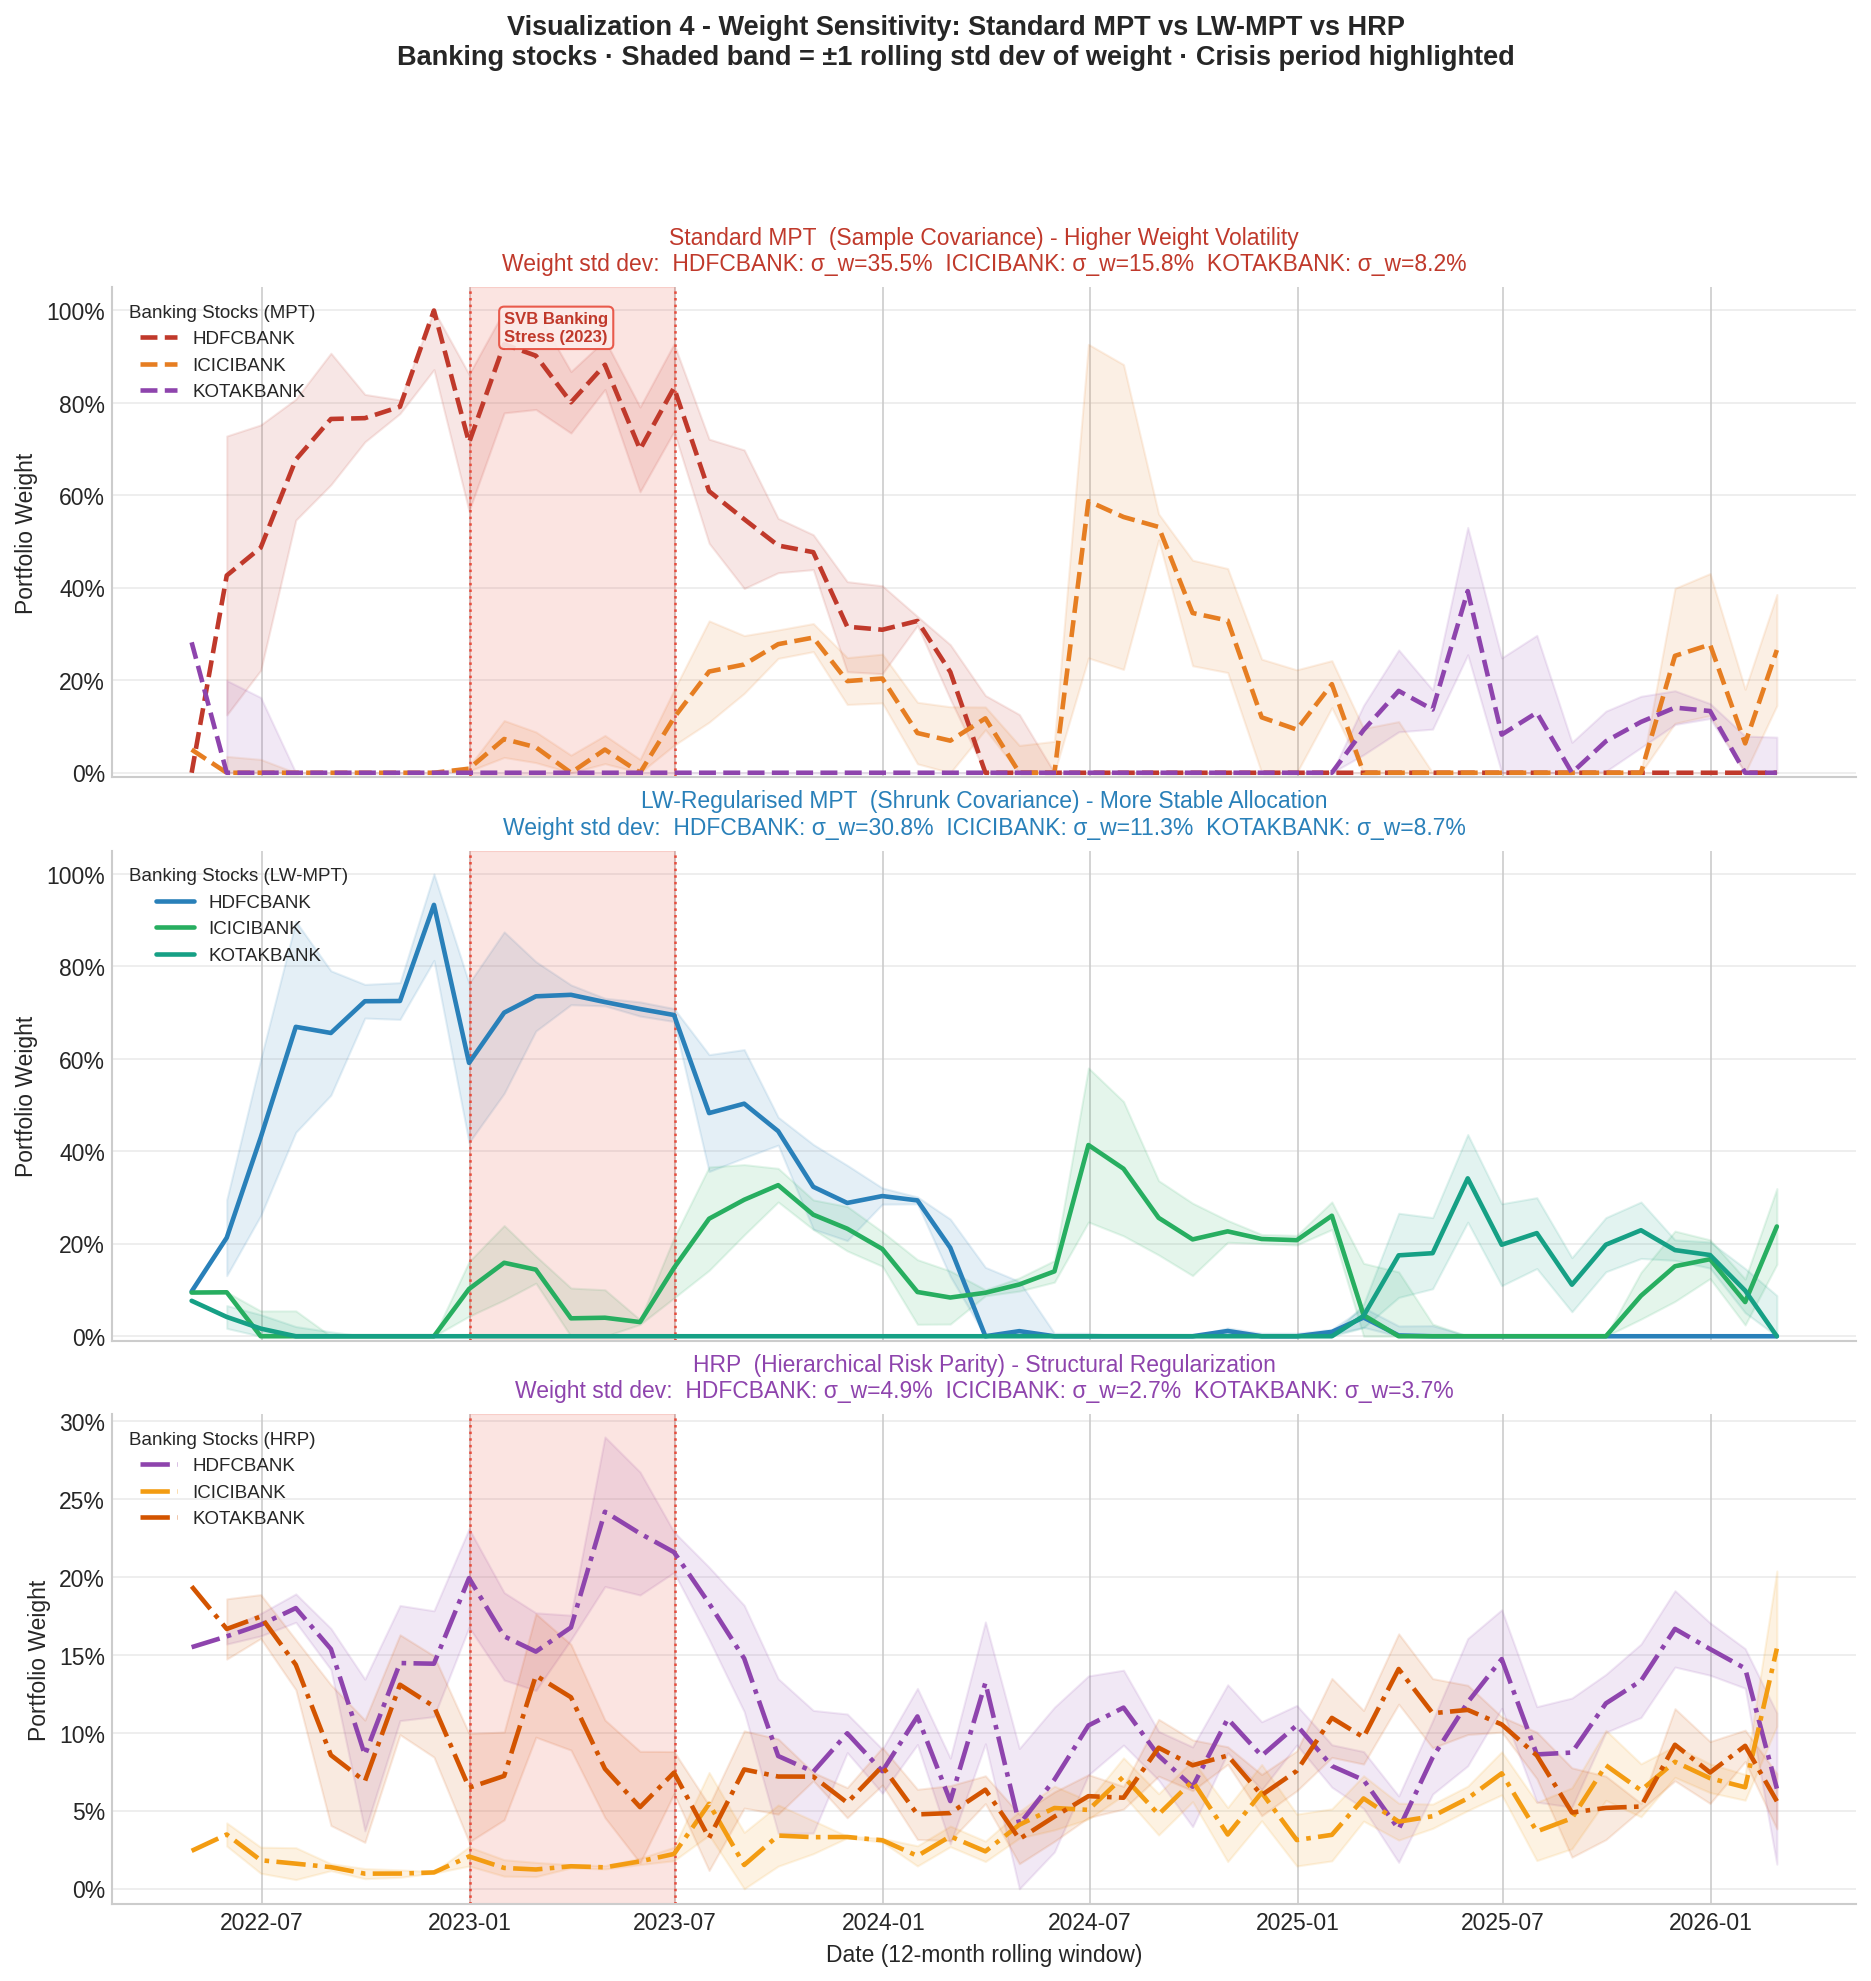

Saved: viz4_weight_sensitivity_all.png

Weight Volatility Summary - Banking Stocks:
Stock            MPT  σ_w   LW-MPT  σ_w   HRP  σ_w
                                                    
HDFCBANK          35.52%       30.83%       4.90%
ICICIBANK         15.84%       11.31%       2.70%
KOTAKBANK          8.15%        8.67%       3.71%


In [ ]:
#  Visualization 4 - Weight Sensitivity (All 3 Models) 
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True,
                          gridspec_kw={'hspace': 0.15})
PALETTE_HRP = ['#8e44ad', '#f39c12', '#d35400']    # purple/gold/orange for HRP
for j, bank in enumerate(BANKING_STOCKS):
    # MPT (top panel)
    axes[0].plot(dates_np, df_mpt_roll[bank].to_numpy(),
                 color=PALETTE_MPT[j], lw=2.2, ls='--', label=bank, zorder=3)
    # Rolling std band
    axes[0].fill_between(dates_np,
                          np.clip(df_mpt_roll[bank].to_numpy() - df_mpt_roll[bank].rolling(3, min_periods=1).std().to_numpy(), 0, None),
                          np.clip(df_mpt_roll[bank].to_numpy() + df_mpt_roll[bank].rolling(3, min_periods=1).std().to_numpy(), None, 1),
                          alpha=0.12, color=PALETTE_MPT[j])
    # LW (middle panel)
    axes[1].plot(dates_np, df_lw_roll[bank].to_numpy(),
                 color=PALETTE_LW[j], lw=2.2, ls='-', label=bank, zorder=3)
    axes[1].fill_between(dates_np,
                          np.clip(df_lw_roll[bank].to_numpy() - df_lw_roll[bank].rolling(3, min_periods=1).std().to_numpy(), 0, None),
                          np.clip(df_lw_roll[bank].to_numpy() + df_lw_roll[bank].rolling(3, min_periods=1).std().to_numpy(), None, 1),
                          alpha=0.12, color=PALETTE_LW[j])
    # HRP (bottom panel)
    axes[2].plot(dates_np, df_hrp_roll[bank].to_numpy(),
                 color=PALETTE_HRP[j], lw=2.2, ls='-.', label=bank, zorder=3)
    axes[2].fill_between(dates_np,
                          np.clip(df_hrp_roll[bank].to_numpy() - df_hrp_roll[bank].rolling(3, min_periods=1).std().to_numpy(), 0, None),
                          np.clip(df_hrp_roll[bank].to_numpy() + df_hrp_roll[bank].rolling(3, min_periods=1).std().to_numpy(), None, 1),
                          alpha=0.12, color=PALETTE_HRP[j])
for ax in axes:
    # Crisis shading
    ax.axvspan(CRISIS_START, CRISIS_END, alpha=0.15, color='#e74c3c', zorder=1)
    ax.axvline(CRISIS_START, color='#e74c3c', lw=1.2, ls=':', zorder=2)
    ax.axvline(CRISIS_END,   color='#e74c3c', lw=1.2, ls=':', zorder=2)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Portfolio Weight', fontsize=11)
    ax.set_ylim(bottom=-0.01)
    ax.grid(axis='y', alpha=0.4)
# Crisis label
ypos = axes[0].get_ylim()[1] * 0.95
axes[0].text(CRISIS_START + pd.Timedelta(days=30), ypos,
             'SVB Banking\nStress (2023)', fontsize=8, color='#c0392b',
             va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', ec='#e74c3c', alpha=0.9))
# Stock legends
axes[0].legend(title='Banking Stocks (MPT)', fontsize=9, title_fontsize=9,
               loc='upper left', framealpha=0.9)
axes[1].legend(title='Banking Stocks (LW-MPT)', fontsize=9, title_fontsize=9,
               loc='upper left', framealpha=0.9)
axes[2].legend(title='Banking Stocks (HRP)', fontsize=9, title_fontsize=9,
               loc='upper left', framealpha=0.9)
# Sub-titles with volatility stats
vol_hrp_str = '  '.join([f'{b}: σ_w={df_hrp_roll[b].std():.1%}' for b in BANKING_STOCKS])
axes[0].set_title(f'Standard MPT  (Sample Covariance) - Higher Weight Volatility\n'
                  f'Weight std dev:  {vol_mpt_str}',
                  fontsize=11, pad=8, color='#c0392b')
axes[1].set_title(f'LW-Regularised MPT  (Shrunk Covariance) - More Stable Allocation\n'
                  f'Weight std dev:  {vol_lw_str}',
                  fontsize=11, pad=8, color='#2980b9')
axes[2].set_title(f'HRP  (Hierarchical Risk Parity) - Structural Regularization\n'
                  f'Weight std dev:  {vol_hrp_str}',
                  fontsize=11, pad=8, color='#8e44ad')
axes[2].set_xlabel('Date (12-month rolling window)', fontsize=11)
fig.suptitle(
    'Visualization 4 - Weight Sensitivity: Standard MPT vs LW-MPT vs HRP\n'
    'Banking stocks · Shaded band = ±1 rolling std dev of weight · Crisis period highlighted',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('viz4_weight_sensitivity_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz4_weight_sensitivity_all.png')
# Table summary
print('\nWeight Volatility Summary - Banking Stocks:')
print(f'{"Stock":<14} {"MPT  σ_w":>10} {"LW-MPT  σ_w":>13} {"HRP  σ_w":>10}')
print(' ' * 52)
for bank in BANKING_STOCKS:
    vm = df_mpt_roll[bank].std()
    vl = df_lw_roll[bank].std()
    vh = df_hrp_roll[bank].std()
    print(f'{bank:<14} {vm:>9.2%} {vl:>12.2%} {vh:>11.2%}')




In [330]:
#  Final Summary 
print('=' * 65)
print('  ASSIGNMENT III - SUMMARY OF RESULTS')
print('=' * 65)
print()
print('  PART 1 - LEDOIT-WOLF SHRINKAGE (Monthly Returns)')
print('  ' + '-' * 55)
print(f'  Sample Cov condition number κ_S : {kappa_S:>10,.2f}')
print(f'  LW Shrunk condition number κ_LW : {kappa_LW:>10,.2f}')
print(f'  Shrinkage intensity α : {alpha_lw:>10.4f}')
print(f'  κ improvement factor : {kappa_S/kappa_LW:>10.1f}×')
print()
print(f'  Max Sharpe - Sample MPT  HHI : {np.sum(w_mpt.values**2):.4f}  (concentrated)')
print(f'  Max Sharpe - LW MPT HHI : {np.sum(w_lw.values**2):.4f}  (diversified)')
print()
print('  PART 2 - HRP (Daily Returns)')
print('  ' + '-' * 55)
print(f'  HRP weights (training) HHI : {np.sum(w_hrp.values**2):.4f}')
print(f'  Min-Var MPT HHI : {np.sum(w_mpt_d.values**2):.4f}')
print()
print(f'  Average turnover - HRP : {to_hrp:.2%}')
print(f'  Average turnover - Min-Var MPT  : {to_mpt_mv:.2%}')
print(f'  Turnover reduction (HRP vs MPT) : {(1 - to_hrp/to_mpt_mv):.1%}')
print()
print('=' * 65)




  ASSIGNMENT III - SUMMARY OF RESULTS

  PART 1 - LEDOIT-WOLF SHRINKAGE (Monthly Returns)
  -------------------------------------------------------
  Sample Cov condition number κ_S :      35.60
  LW Shrunk condition number κ_LW :      14.96
  Shrinkage intensity α :     0.1698
  κ improvement factor :        2.4×

  Max Sharpe - Sample MPT  HHI : 0.2792  (concentrated)
  Max Sharpe - LW MPT HHI : 0.2672  (diversified)

  PART 2 - HRP (Daily Returns)
  -------------------------------------------------------
  HRP weights (training) HHI : 0.1023
  Min-Var MPT HHI : 0.1484

  Average turnover - HRP : 9.11%
  Average turnover - Min-Var MPT  : 15.46%
  Turnover reduction (HRP vs MPT) : 41.1%

